In [96]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [97]:
def fungsi_satu(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if (img[i, j] > batas):
                canvas[i, j] = 255
            elif (img[i, j] <= batas):
                canvas[i, j] = 0
    return canvas

In [98]:
def fungsi_dua(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

In [99]:
def metode_satu(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
    return hasil

In [100]:
def metode_dua(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

In [101]:
def metode_tiga(img):
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True
    while changed:
        changed = False
        hapus = []
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]
                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1
                if (2 <= jumlah <= 6 and transisi == 1 and P2 * P4 * P6 == 0 and P4 * P6 * P8 == 0):
                    hapus.append((i, j))
                    changed = True
        for i, j in hapus:
            binary[i, j] = 0
        hapus = []
        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]
                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1
                if (2 <= jumlah <= 6 and transisi == 1 and P2 * P4 * P8 == 0 and P2 * P6 * P8 == 0):
                    hapus.append((i, j))
                    changed = True
        for i, j in hapus:
            binary[i, j] = 0
    return binary * 255

In [102]:
def metode_empat(img, kernel, iterasi=1):
    hasil = img.copy()
    for _ in range(iterasi):
        hasil = metode_satu(hasil, kernel)
    return hasil

In [103]:
kernel_diamond = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
], dtype=np.uint8)

kernel_cross = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

kernel_x = np.array([
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1]
], dtype=np.uint8)

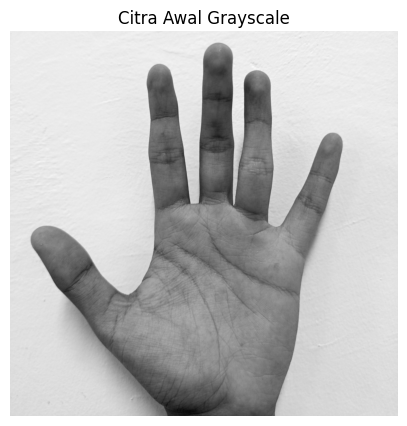

In [104]:
img_awal = cv2.imread('Assets/tangan.jpeg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5, 5))
plt.imshow(img_awal, cmap='gray')
plt.title("Citra Awal Grayscale")
plt.axis('off')
plt.show()

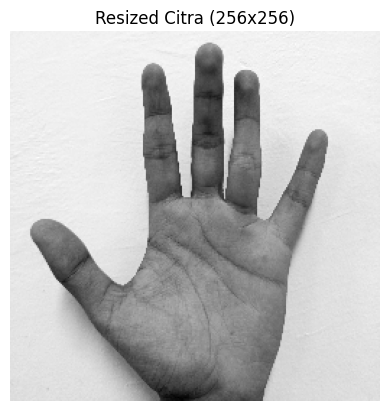

In [105]:
citra_resized = fungsi_dua(img_awal, new_width=256, new_height=256)
plt.imshow(citra_resized, cmap='gray')
plt.title("Resized Citra (256x256)")
plt.axis('off')
plt.show()

In [106]:
def convolution(img, kernel):
    # Ukuran kernel
    size = kernel.shape[0]
    
    # Ukuran padding
    pad_size = size // 2
    
    # Tambah padding nol (constant)
    padded = np.pad(img, pad_size, mode='constant')
    
    # Kanvas hasil (gunakan float32 untuk menampung nilai negatif/desimal)
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            # Area kernel
            region = padded[i:i+size, j:j+size]
            # Hitung konvolusi: jumlah dari perkalian region dengan kernel
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas
# --- Kernel Perbaikan Citra ---
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

# --- Kernel Sobel ---
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# --- Kernel Prewitt ---
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# --- Kernel Roberts ---
robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)
def edge_detection(img, kernelx, kernely):
    # Konvolusi sumbu x dan y
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    # Gabung gradien absolut agar tidak ada nilai negatif
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke rentang 0-255
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    # Batas nilai (clip) dan konversi ke uint8
    return np.clip(canvas, 0, 255).astype(np.uint8)

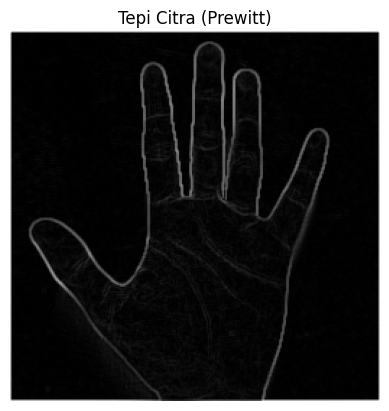

In [107]:
citra_tepi_prewitt = edge_detection(citra_resized, prewittx, prewitty)
plt.imshow(citra_tepi_prewitt, cmap='gray')
plt.title("Tepi Citra (Prewitt)")
plt.axis('off')
plt.show()

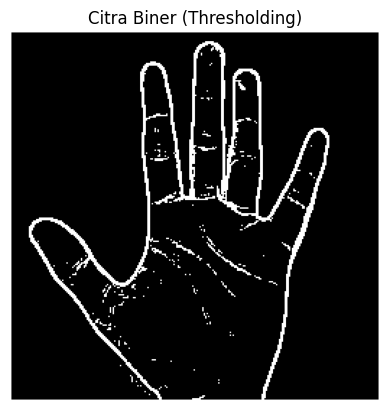

In [108]:
citra_biner = fungsi_satu(citra_tepi_prewitt, batas=20)
plt.imshow(citra_biner, cmap='gray')
plt.title("Citra Biner (Thresholding)")
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

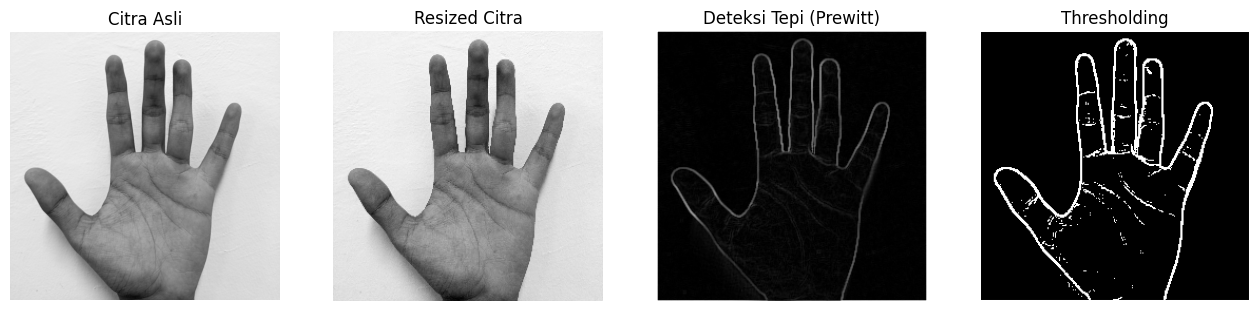

In [109]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 4, 1)
plt.imshow(img_awal, cmap='gray')
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(citra_resized, cmap='gray')
plt.title("Resized Citra")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(citra_tepi_prewitt, cmap='gray')
plt.title("Deteksi Tepi (Prewitt)")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(citra_biner, cmap='gray')
plt.title("Thresholding")
plt.axis('off')

In [110]:
print(citra_resized)

[[197 195 194 ... 194 193 194]
 [196 193 194 ... 193 195 194]
 [192 192 196 ... 195 193 193]
 ...
 [184 182 184 ... 185 185 183]
 [182 181 181 ... 183 185 182]
 [183 181 184 ... 184 183 186]]


In [111]:
kernel33 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

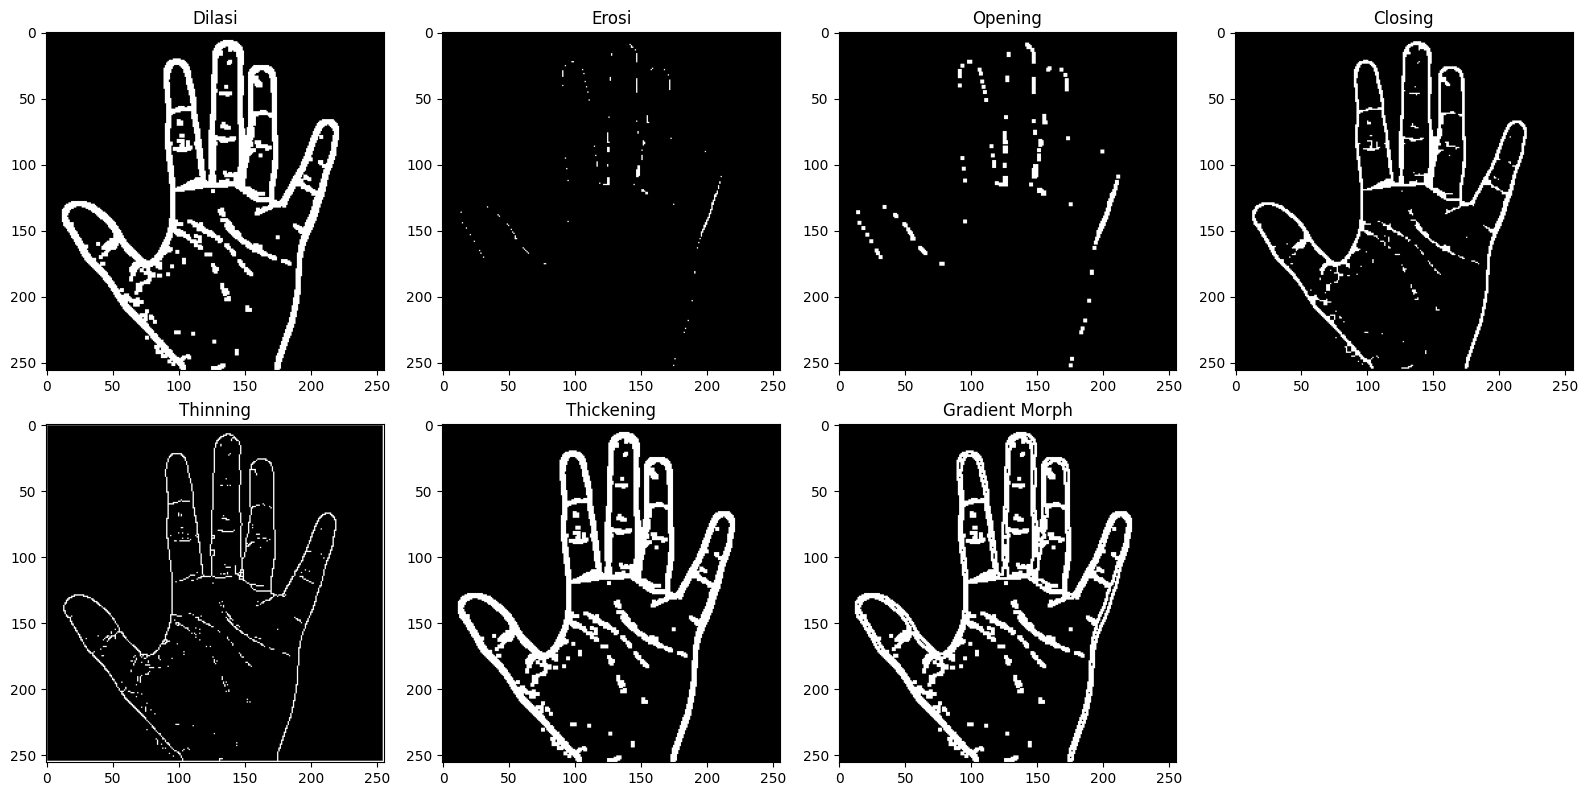

In [112]:
c_dilasi = metode_satu(citra_biner, kernel33)
c_erosi = metode_dua(citra_biner, kernel33)

c_langkah_erosi = metode_dua(citra_biner, kernel33)
c_opening = metode_satu(c_langkah_erosi, kernel33)

c_langkah_dilasi = metode_satu(citra_biner, kernel33)
c_closing = metode_dua(c_langkah_dilasi, kernel33)

c_thinning = metode_tiga(citra_biner)
c_thickening = metode_empat(citra_biner, kernel33, iterasi=1)
c_gradient = c_dilasi - c_erosi

plt.figure(figsize=(16, 8))
plt.subplot(2, 4, 1); plt.imshow(c_dilasi, cmap='gray'); plt.title("Dilasi"); plt.axis('on')
plt.subplot(2, 4, 2); plt.imshow(c_erosi, cmap='gray'); plt.title("Erosi"); plt.axis('on')
plt.subplot(2, 4, 3); plt.imshow(c_opening, cmap='gray'); plt.title("Opening"); plt.axis('on')
plt.subplot(2, 4, 4); plt.imshow(c_closing, cmap='gray'); plt.title("Closing"); plt.axis('on')
plt.subplot(2, 4, 5); plt.imshow(c_thinning, cmap='gray'); plt.title("Thinning"); plt.axis('on')
plt.subplot(2, 4, 6); plt.imshow(c_thickening, cmap='gray'); plt.title("Thickening"); plt.axis('on')
plt.subplot(2, 4, 7); plt.imshow(c_gradient, cmap='gray'); plt.title("Gradient Morph"); plt.axis('on')
plt.tight_layout()
plt.show()

In [113]:
kernel55 = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
], dtype=np.uint8)

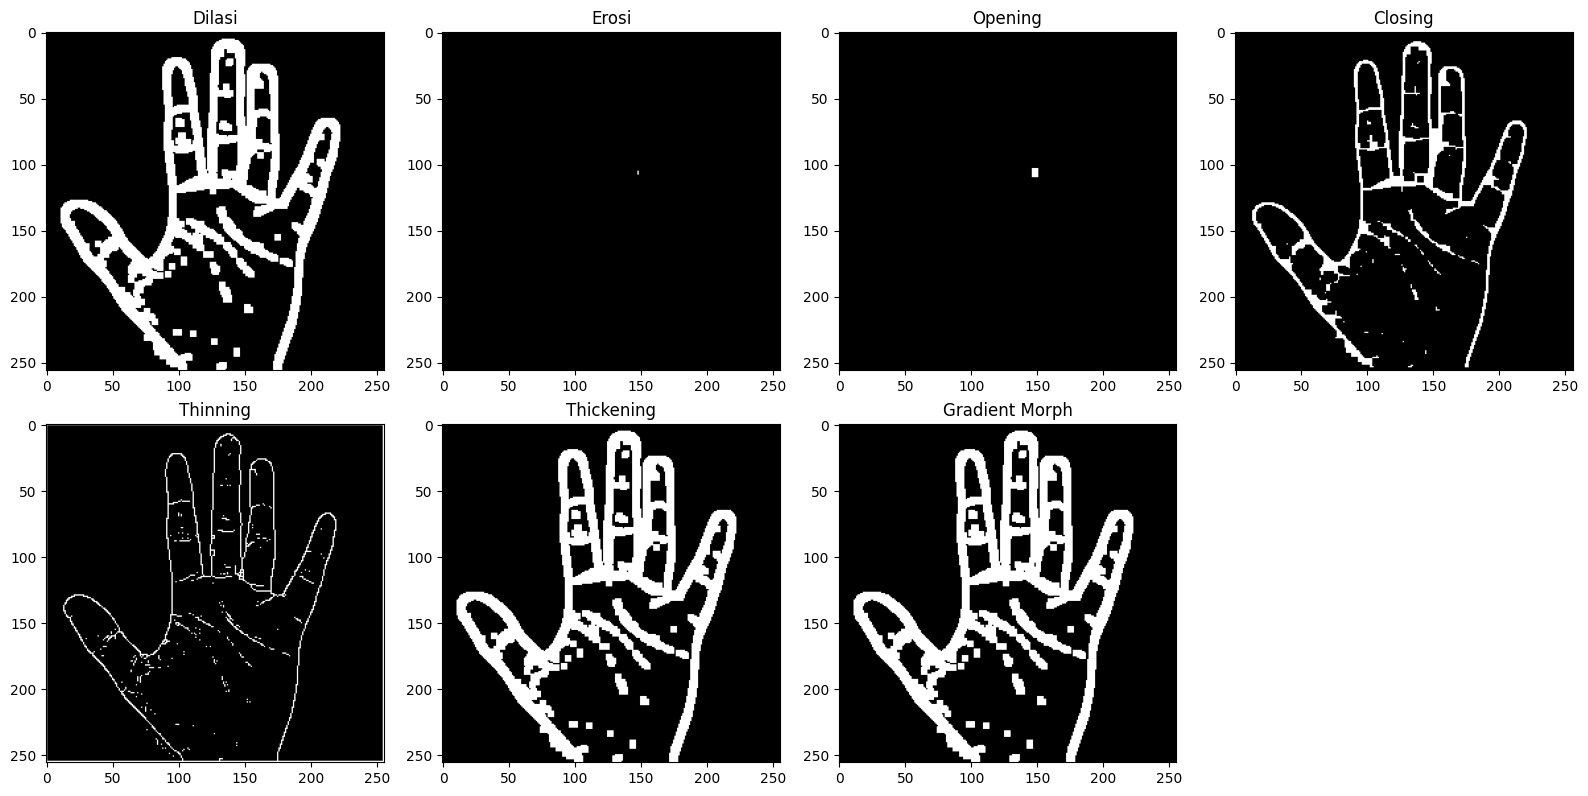

In [114]:
d_dilasi = metode_satu(citra_biner, kernel55)
d_erosi = metode_dua(citra_biner, kernel55)

d_langkah_erosi = metode_dua(citra_biner, kernel55)
d_opening = metode_satu(d_langkah_erosi, kernel55)

d_langkah_dilasi = metode_satu(citra_biner, kernel55)
d_closing = metode_dua(d_langkah_dilasi, kernel55)

d_thinning = metode_tiga(citra_biner)
d_thickening = metode_empat(citra_biner, kernel55, iterasi=1)
d_gradient = d_dilasi - d_erosi

plt.figure(figsize=(16, 8))
plt.subplot(2, 4, 1); plt.imshow(d_dilasi, cmap='gray'); plt.title("Dilasi"); plt.axis('on')
plt.subplot(2, 4, 2); plt.imshow(d_erosi, cmap='gray'); plt.title("Erosi"); plt.axis('on')
plt.subplot(2, 4, 3); plt.imshow(d_opening, cmap='gray'); plt.title("Opening"); plt.axis('on')
plt.subplot(2, 4, 4); plt.imshow(d_closing, cmap='gray'); plt.title("Closing"); plt.axis('on')
plt.subplot(2, 4, 5); plt.imshow(d_thinning, cmap='gray'); plt.title("Thinning"); plt.axis('on')
plt.subplot(2, 4, 6); plt.imshow(d_thickening, cmap='gray'); plt.title("Thickening"); plt.axis('on')
plt.subplot(2, 4, 7); plt.imshow(d_gradient, cmap='gray'); plt.title("Gradient Morph"); plt.axis('on')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Kombinasi Opening + Closing')

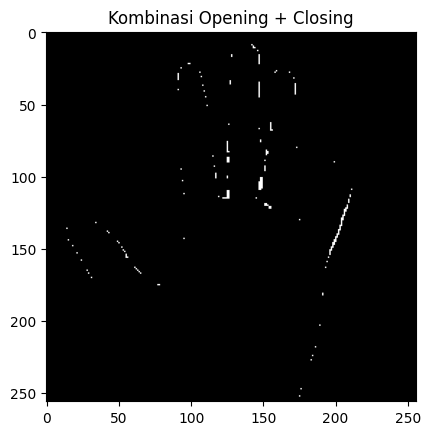

In [115]:
c_closing1 = metode_dua(c_opening, kernel33)
plt.imshow(c_closing1, cmap='gray')
plt.title("Kombinasi Opening + Closing")

Text(0.5, 1.0, 'Kombinasi Opening + Dilasi')

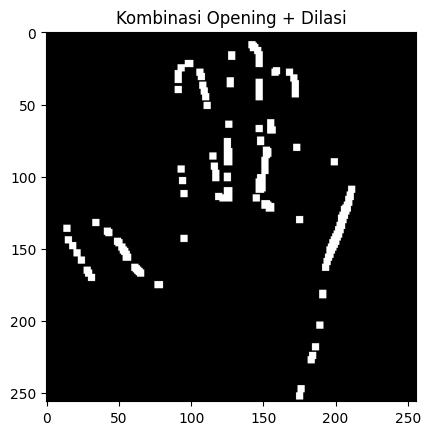

In [116]:
c_dilasi1 = metode_satu(c_opening, kernel33)
plt.imshow(c_dilasi1, cmap='gray')
plt.title("Kombinasi Opening + Dilasi")

Text(0.5, 1.0, 'Kombinasi Closing + Opening')

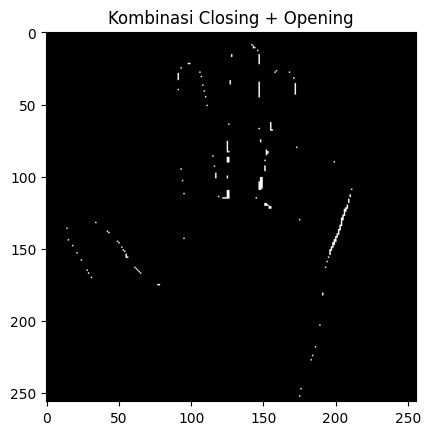

In [117]:
c_closing2 = metode_dua(c_opening, kernel33)
plt.imshow(c_closing2, cmap='gray')
plt.title("Kombinasi Closing + Opening")

Text(0.5, 1.0, 'Kombinasi Closing + Erosi')

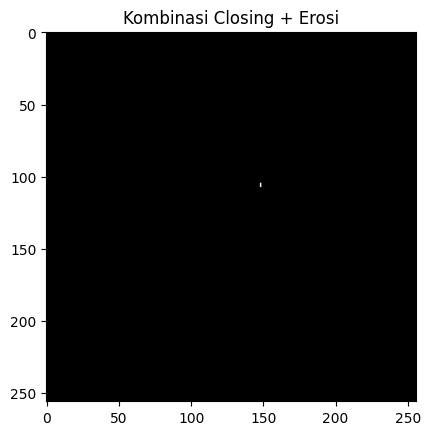

In [118]:
c_closing3 = metode_dua(c_erosi, kernel33)
plt.imshow(c_closing3, cmap='gray')
plt.title("Kombinasi Closing + Erosi")

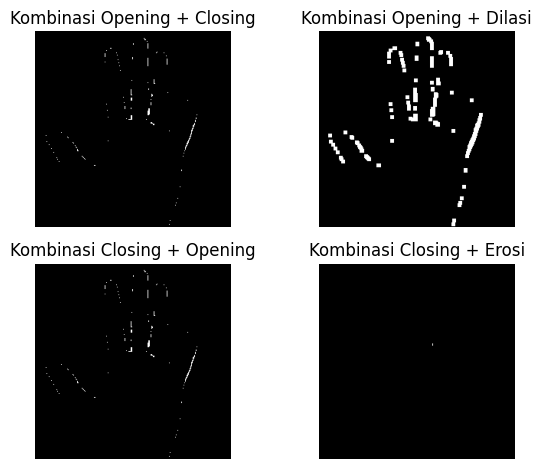

In [119]:
plt.subplot(2, 2, 1); plt.imshow(c_closing1, cmap='gray'); plt.title("Kombinasi Opening + Closing"); plt.axis('off')
plt.subplot(2, 2, 2); plt.imshow(c_dilasi1, cmap='gray'); plt.title("Kombinasi Opening + Dilasi"); plt.axis('off')
plt.subplot(2, 2, 3); plt.imshow(c_closing2, cmap='gray'); plt.title("Kombinasi Closing + Opening"); plt.axis('off')
plt.subplot(2, 2, 4); plt.imshow(c_closing3, cmap='gray'); plt.title("Kombinasi Closing + Erosi"); plt.axis('off')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Kombinasi Opening + Closing')

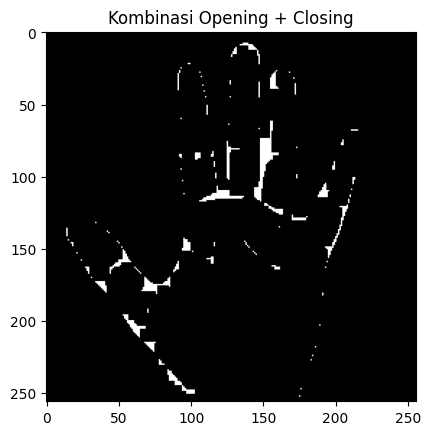

In [120]:
citra_kombinasi = citra_biner

gabung1    = d_opening + d_closing
kombinasi1 = metode_dua(gabung1, kernel33)

plt.imshow(kombinasi1, cmap='gray')
plt.title("Kombinasi Opening + Closing")

Text(0.5, 1.0, 'Kombinasi Opening + Dilasi')

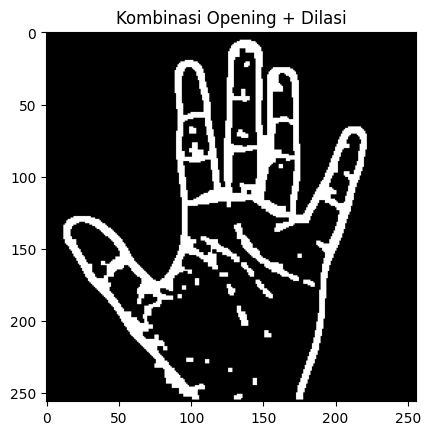

In [121]:
gabung2    = d_opening + d_dilasi
kombinasi2 = metode_dua(gabung2, kernel33)

plt.imshow(kombinasi2, cmap='gray')
plt.title("Kombinasi Opening + Dilasi")

Text(0.5, 1.0, 'Kombinasi Closing + Opening')

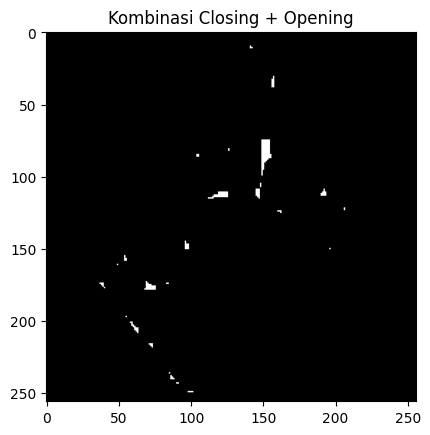

In [122]:
gabung3    = d_closing + d_opening
kombinasi3 = metode_dua(gabung3, kernel55)

plt.imshow(kombinasi3, cmap='gray')
plt.title("Kombinasi Closing + Opening")

Text(0.5, 1.0, 'Kombinasi Closing + Erosi')

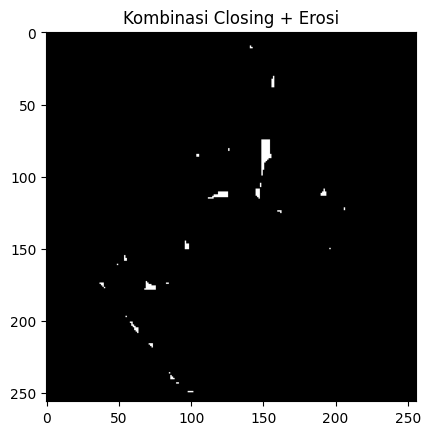

In [123]:
gabung4    = d_closing + d_erosi
kombinasi4 = metode_dua(gabung4, kernel55)

plt.imshow(kombinasi4, cmap='gray')
plt.title("Kombinasi Closing + Erosi")

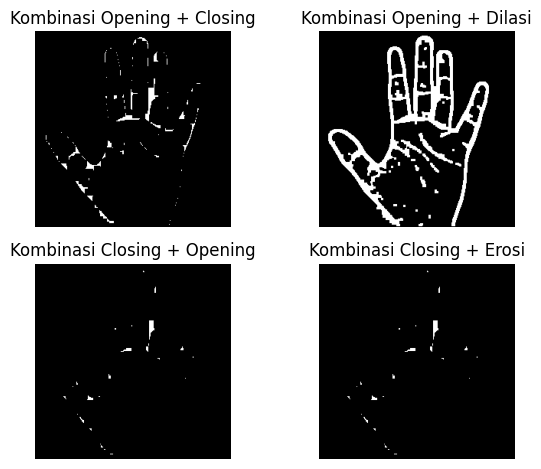

In [124]:
plt.subplot(2, 2, 1); plt.imshow(kombinasi1, cmap='gray'); plt.title("Kombinasi Opening + Closing"); plt.axis('off')
plt.subplot(2, 2, 2); plt.imshow(kombinasi2, cmap='gray'); plt.title("Kombinasi Opening + Dilasi"); plt.axis('off')
plt.subplot(2, 2, 3); plt.imshow(kombinasi3, cmap='gray'); plt.title("Kombinasi Closing + Opening"); plt.axis('off')
plt.subplot(2, 2, 4); plt.imshow(kombinasi4, cmap='gray'); plt.title("Kombinasi Closing + Erosi"); plt.axis('off')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'final ')

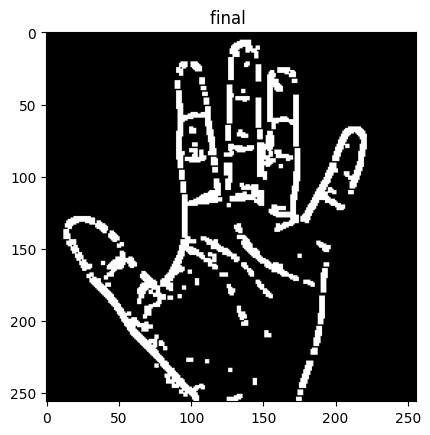

In [128]:
final= c_dilasi - c_erosi
final_erosi = metode_dua(final , kernel33)
final_opening = metode_satu(final_erosi, kernel33)

plt.imshow(final_opening, cmap='gray')
plt.title("final ")